### Exercise Report for Course: Stochastic Simulation

0. Library Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import geom
from scipy.stats.sampling import DiscreteAliasUrn
from scipy.stats import chisquare
import time
import random
import math
import simpy
import pandas as pd

#### Day 4 Exercise - Variance Reduction Methods

Part 1: Crude Monte Carlo

In [2]:
# Set the seed for reporoducability
np.random.seed(42)

outputs = []

# 100 samples
n = 100

for i in range(n):
    # Generate a random sample from uniform distribution
    sample = np.random.uniform(0, 1)
    X = np.exp(sample)
    outputs.append(X)

# Compute Monte Carlo Estimate
theta_crude = np.mean(outputs)
crude_variance = np.var(outputs, ddof=1) 
print("Crude MC Estimation Summary:") 
print(f"Theta (Estimate): {theta_crude:.4f}")
print(f"Sample Variance: {crude_variance:.4f}")
print(f"Standard Error: {math.sqrt(crude_variance / n):.4f}")

# Calculate CI
ci_lower_crude = theta_crude - 1.96 * math.sqrt(crude_variance / n)
ci_upper_crude = theta_crude + 1.96 * math.sqrt(crude_variance / n)
print(f"95% CI: ({ci_lower_crude:.4f}, {ci_upper_crude:.4f})")

# True value of Theta should be: 𝜃 = ~ 1.7183
# So, the estimate is not too far off. 

Crude MC Estimation Summary:
Theta (Estimate): 1.6721
Sample Variance: 0.2501
Standard Error: 0.0500
95% CI: (1.5740, 1.7701)


Part 2: Antithetic Variables

In [3]:
np.random.seed(42)

antithetic_thetas = []

# Same N
for i in range(n):
    # Generate a random sample from uniform distribution
    sample = np.random.uniform(0, 1)
    Y = (np.exp(sample) + np.exp(1 - sample)) / 2
    antithetic_thetas.append(Y)

theta_anti = np.mean(antithetic_thetas)
sample_variance = np.var(antithetic_thetas, ddof=1)  
print("Antithetic Variable Estimation Summary:")
print(f"Theta (Estimate): {theta_anti:.4f}")
print(f"Sample Variance: {sample_variance:.4f}")
print(f"Standard Error: {math.sqrt(sample_variance / n):.4f}")

# Calculate CI
ci_lower_anti = theta_anti - 1.96 * math.sqrt(sample_variance / n)
ci_upper_anti = theta_anti + 1.96 * math.sqrt(sample_variance / n)
print(f"95% CI: ({ci_lower_anti:.4f}, {ci_upper_anti:.4f})")

Antithetic Variable Estimation Summary:
Theta (Estimate): 1.7226
Sample Variance: 0.0039
Standard Error: 0.0063
95% CI: (1.7103, 1.7349)


Part 3: Control Variate

In [4]:
# Generate U, X, Z
U = np.random.uniform(0, 1, n)
X = np.exp(U)      # target
Z = U              # control variate
mu_Z = 0.5        # E[U]

# Estimate covariance and variance from samples
mean_X = np.mean(X)
mean_Z = np.mean(Z)

cov_XZ = np.mean((X - mean_X) * (Z - mean_Z))
var_Z = np.var(Z, ddof=1)

# Optimal control variate coefficient
c = -cov_XZ / var_Z

# Construct control variate observations
Y = X + c * (Z - mu_Z)

theta_control = np.mean(Y)
sample_variance_control = np.var(Y, ddof=1)

print("Control Variate Estimation Summary:")
print(f"Theta (Estimate): {theta_control:.4f}")
print(f"Sample Variance: {sample_variance_control:.6f}")
print(f"Standard Error: {math.sqrt(sample_variance_control / n):.6f}")

ci_lower_control = theta_control - 1.96 * math.sqrt(sample_variance_control / n)
ci_upper_control = theta_control + 1.96 * math.sqrt(sample_variance_control / n)
print(f"95% CI: ({ci_lower_control:.4f}, {ci_upper_control:.4f})")


# ? should use the analytical mean and variance

Control Variate Estimation Summary:
Theta (Estimate): 1.7200
Sample Variance: 0.003591
Standard Error: 0.005993
95% CI: (1.7083, 1.7318)


Part 4: Stratified Sampling

In [5]:
stratified = []

# Same N
for i in range(n):
    a  = i / n
    b = (i + 1) / n
    # Generate a random sample from uniform distribution
    U = a + (b - a) * np.random.uniform(0, 1)

    # Compute X
    X = np.exp(U)
    stratified.append(X)

theta_stratified = np.mean(stratified)
sample_variance_stratified = np.var(stratified, ddof=1)
SE = np.sqrt(sample_variance_stratified / n)
print("Stratified Sampling Estimation Summary:")
print(f"Theta (Estimate): {theta_stratified:.4f}")
print(f"Sample Variance: {sample_variance_stratified:.4f}")
print(f"Standard Error: {SE:.4f}")

# Calculate CI
ci_lower_stratified = theta_stratified - 1.96 * SE
ci_upper_stratified = theta_stratified + 1.96 * SE
print(f"95% CI: ({ci_lower_stratified:.4f}, {ci_upper_stratified:.4f})")

Stratified Sampling Estimation Summary:
Theta (Estimate): 1.7186
Sample Variance: 0.2442
Standard Error: 0.0494
95% CI: (1.6217, 1.8154)


Visualise explored Variance reduction methods

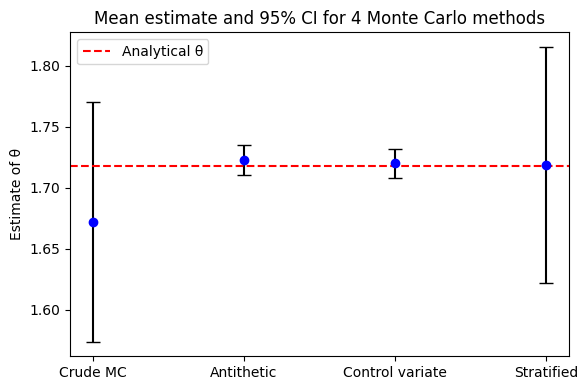

In [6]:
methods = ["Crude MC", "Antithetic", "Control variate", "Stratified"]
estimates = [theta_crude, theta_anti, theta_control, theta_stratified]
ci_lower = [ci_lower_crude, ci_lower_anti, ci_lower_control, ci_lower_stratified]
ci_upper = [ci_upper_crude, ci_upper_anti, ci_upper_control, ci_upper_stratified]

lower_errors = np.array(estimates) - np.array(ci_lower)
upper_errors = np.array(ci_upper) - np.array(estimates)

error = [lower_errors, upper_errors]


x_pos = np.arange(len(methods))

plt.figure(figsize=(6, 4))
plt.errorbar(
    x_pos,
    estimates,
    yerr=error,
    fmt='o',
    capsize=5,
    ecolor='black',
    color='blue'
)

plt.xticks(x_pos, methods)
plt.ylabel("Estimate of θ")
plt.title("Mean estimate and 95% CI for 4 Monte Carlo methods")

plt.axhline(np.e - 1, color='red', linestyle='--', label='Analytical θ')
plt.legend()

plt.tight_layout()
plt.show()


### Part 7 of Exercise 5 : Importance Sampling

In [7]:
np.random.seed(42)

rows = []  

# Parameters
a_values = [2, 4]
n_values = [100, 1_000, 10_000]

for a in a_values:
    for n in n_values:


        Z = np.random.normal(0, 1, n)
        X = (Z > a).astype(float)

        p_hat = np.mean(X)
        var_hat = np.var(X, ddof=1)
        SE = np.sqrt(var_hat / n)
        CI = (round(p_hat - 1.96*SE, 6), round(p_hat + 1.96*SE, 6))

        rows.append({
            "a": a,
            "n": n,
            "Method": "Crude MC",
            "Estimate": p_hat,
            "Variance": var_hat,
            "Std Error": SE,
            "95% CI": CI
        })

        Y = np.random.normal(a, 1, n)
        w = stats.norm.pdf(Y, 0, 1) / stats.norm.pdf(Y, a, 1)

        X_IS = (Y > a).astype(float)
        weighted = w * X_IS

        p_hat_IS = np.mean(weighted)
        var_IS = np.var(weighted, ddof=1)
        SE_IS = np.sqrt(var_IS / n)
        CI_IS = (round(p_hat_IS - 1.96*SE_IS, 6), round(p_hat_IS + 1.96*SE_IS, 6))

        rows.append({
            "a": a,
            "n": n,
            "Method": "Importance Sampling",
            "Estimate": p_hat_IS,
            "Variance": var_IS,
            "Std Error": SE_IS,
            "95% CI": CI_IS
        })

result_df = pd.DataFrame(rows)
result_df

# For the discussion
# Crude MC fails for large a values
# Importance Sampling performs better in these cases, it remains stable
# Variance reduction is noticable between crude and importance sampling methods, and IS also has narrower CI 

,a,n,Method,Estimate,Variance,Std Error,95% CI
0,2,100,Crude MC,0.000000,0.000000e+00,0.000000e+00,"(0.0, 0.0)"
1,2,100,Importance Sampling,0.028225,1.422394e-03,3.771463e-03,"(0.020833, 0.035617)"
2,2,1000,Crude MC,0.029000,2.818719e-02,5.309161e-03,"(0.018594, 0.039406)"
3,2,1000,Importance Sampling,0.023397,1.270070e-03,1.126974e-03,"(0.021189, 0.025606)"
4,2,10000,Crude MC,0.021900,2.142253e-02,1.463644e-03,"(0.019031, 0.024769)"
5,2,10000,Importance Sampling,0.023079,1.248778e-03,3.533806e-04,"(0.022386, 0.023772)"
6,4,100,Crude MC,0.000000,0.000000e+00,0.000000e+00,"(0.0, 0.0)"
7,4,100,Importance Sampling,0.000032,5.589249e-09,7.476128e-06,"(1.7e-05, 4.7e-05)"
8,4,1000,Crude MC,0.000000,0.000000e+00,0.000000e+00,"(0.0, 0.0)"
9,4,1000,Importance Sampling,0.000035,4.921097e-09,2.218355e-06,"(3.1e-05, 4e-05)"


### Part 8 in Exercise 5: Importance sampling

In [8]:
np.random.seed(42)

lambdas_sim = []
empirical_vars = []

lambdas = np.linspace(0.2, 5, 400)
n = 100_000

for lam in lambdas:
    X = np.random.exponential(scale=1/lam, size=n)

    mask = (X >= 0) & (X <= 1)

    # Weights 
    W = (1/lam) * np.exp((1 + lam) * X[mask])

    I_hat = round(np.mean(W), 6)
    var_hat = round(np.var(W, ddof=1), 6)
    SE = round(np.sqrt(var_hat / len(W)), 6)
    CI = np.array([round(I_hat - 1.96*SE, 6), round(I_hat + 1.96*SE, 6)])
    print(" ")
    print(f"Lambda: {lam}")
    print(f" Mean: {I_hat}, Variance: {var_hat}, Std Error: {SE}, 95% CI: {CI}")
    lambdas_sim.append(lam)
    empirical_vars.append(var_hat)


 
Lambda: 0.2
 Mean: 9.487618, Variance: 10.767363, Std Error: 0.024342, 95% CI: [9.439908 9.535328]
 
Lambda: 0.21203007518796993
 Mean: 9.022237, Variance: 9.952668, Std Error: 0.022869, 95% CI: [8.977414 9.06706 ]
 
Lambda: 0.22406015037593985
 Mean: 8.533996, Variance: 9.1076, Std Error: 0.021347, 95% CI: [8.492156 8.575836]
 
Lambda: 0.2360902255639098
 Mean: 8.165738, Variance: 8.496869, Std Error: 0.020098, 95% CI: [8.126346 8.20513 ]
 
Lambda: 0.2481203007518797
 Mean: 7.834976, Variance: 7.960487, Std Error: 0.019077, 95% CI: [7.797585 7.872367]
 
Lambda: 0.26015037593984963
 Mean: 7.493287, Variance: 7.417715, Std Error: 0.018036, 95% CI: [7.457936 7.528638]
 
Lambda: 0.2721804511278195
 Mean: 7.216592, Variance: 7.028119, Std Error: 0.017239, 95% CI: [7.182804 7.25038 ]
 
Lambda: 0.28421052631578947
 Mean: 6.967397, Variance: 6.688016, Std Error: 0.016463, 95% CI: [6.93513  6.999664]
 
Lambda: 0.2962406015037594
 Mean: 6.698554, Variance: 6.35783, Std Error: 0.01576, 95% CI:

Optimal λ (theoretical): 1.354977488744372
Optimal λ (empirical): 1.0300751879699248


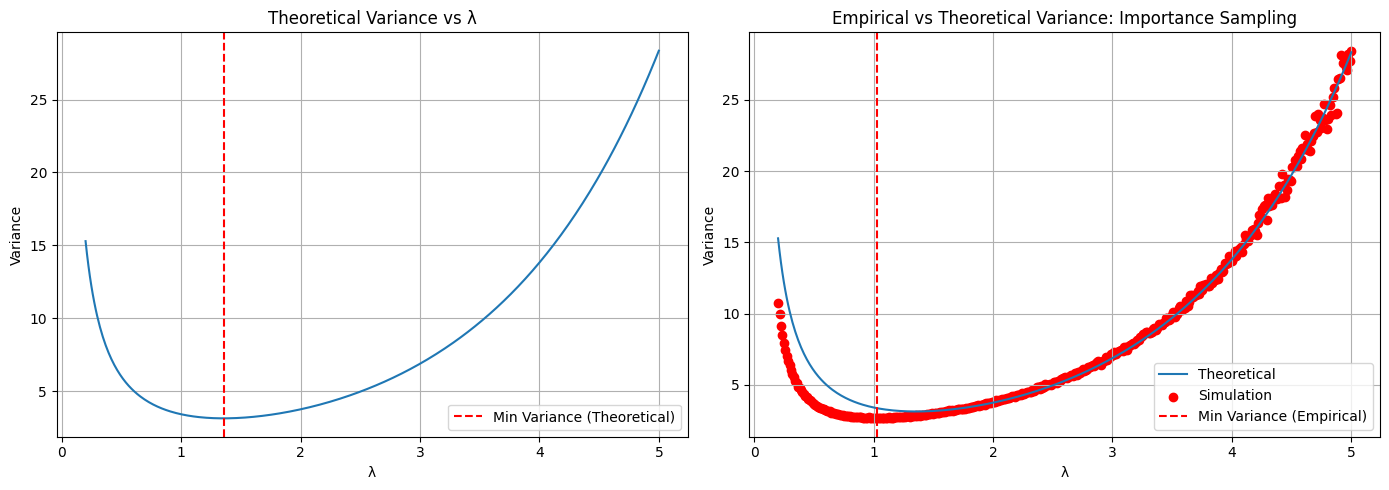

In [9]:
# true value of the integral I = ∫_0^1 e^x dx
I_true = np.e - 1

def var_theoretical(lam):
    return (1/lam) * (np.exp(2 + lam) - 1) / (2 + lam) - I_true**2

lams = np.linspace(0.2, 5, 400)
vars_theory = var_theoretical(lams)

lam_grid = np.linspace(0.2, 5, 2000)
lam_opt = lam_grid[np.argmin(var_theoretical(lam_grid))]
lam_opt_empirical = lambdas_sim[np.argmin(empirical_vars)]
print("Optimal λ (theoretical):", lam_opt)
print("Optimal λ (empirical):", lam_opt_empirical)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Theoretical variance
axes[0].plot(lams, vars_theory)
axes[0].axvline(lam_opt, color='r', linestyle='--', label='Min Variance (Theoretical)')
axes[0].set_title("Theoretical Variance vs λ")
axes[0].set_xlabel("λ")
axes[0].set_ylabel("Variance")
axes[0].grid(True)
axes[0].legend()

# Theoretical + Empirical
axes[1].plot(lams, vars_theory, label="Theoretical")
axes[1].scatter(lambdas_sim, empirical_vars, color="red", label="Simulation")
axes[1].axvline(lam_opt_empirical, color='r', linestyle='--', label='Min Variance (Empirical)')
axes[1].set_title("Empirical vs Theoretical Variance: Importance Sampling")
axes[1].set_xlabel("λ")
axes[1].set_ylabel("Variance")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Notes
# The theoretical optimal λ (≈1.35) is obtained by minimizing the analytic variance of the IS weight under the full proposal distribution.
# The empirical optimal λ (≈1.03) is lower because the implemented estimator effectively conditions on samples in [0,1] and uses only that subset, which changes the variance structure.
# Additionally, finite‑sample Monte Carlo noise and grid discretization contribute to the discrepancy.
# When the implementation is aligned with the theoretical setup and larger sample sizes are used, the empirical minimizer moves closer to the theoretical one.

### Part 9 of Exercise 5: Pareto Distribution X Importance Sampling

In [10]:
k= 2.05
xm = 1.0

# true mean
mu = k * xm / (k - 1)

print("True mean:", mu)

# sample from first moment distribution
X = xm * (1 - np.random.rand(n))**(-1/(k-1))

print("Samples:", X)

# IS estimator
weights = mu / X
mu_hat = np.mean(X * weights)

print("IS estimate:", mu_hat)

print("Is Mean identical to True Mean?", np.isclose(mu_hat, mu))

# This approach is not meaningful, as it requires knowing the true mean, which is not available in practice.

True mean: 1.9523809523809526
Samples: [2.48737186 2.03262015 1.04728603 ... 1.42483844 1.80605222 1.6927687 ]
IS estimate: 1.9523809523809526
Is Mean identical to True Mean? True
